In [33]:
%matplotlib notebook
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Create grid dimensions
grid_size = (100, 100)
x, y = np.meshgrid(np.linspace(-3, 3, grid_size[0]), np.linspace(-3, 3, grid_size[1]))

# Create figure and axis
fig, ax = plt.subplots()

# Initialize the plot with a starting 2D array
initial_data = np.sin(x) * np.cos(y)
im = ax.imshow(initial_data, cmap='viridis', animated=True)

def update(frame):
    # Shift the wave pattern over time using the frame index
    new_data = np.sin(x + frame / 10.0) * np.cos(y + frame / 10.0)
    
    # Update the pixel array data
    im.set_array(new_data)
    
    return im,

def update_dynamic_scale(frame):
    # Simulate a matrix where values explode in scale over time
    new_data = (np.sin(x) * np.cos(y)) * (frame + 1)
    
    # Update the pixel data
    im.set_array(new_data)
    
    # Dynamically adjust the color intensity thresholds
    im.set_clim(vmin=new_data.min(), vmax=new_data.max())
    
    return im,


# Create the animation loop
ani = FuncAnimation(
    fig=fig, 
    func=update, 
    frames=100, 
    interval=50, 
    blit=True
)

plt.show()



<IPython.core.display.Javascript object>

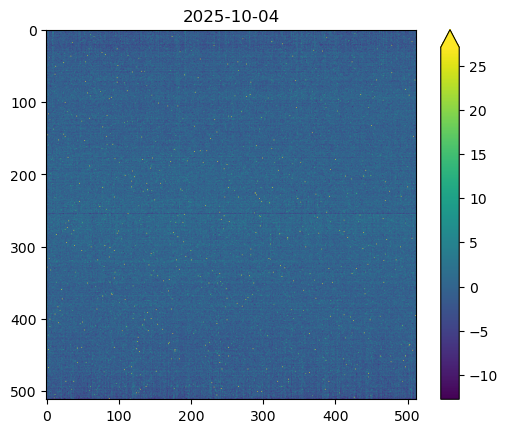

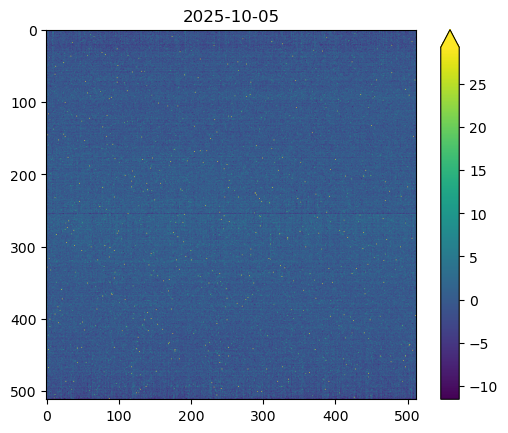

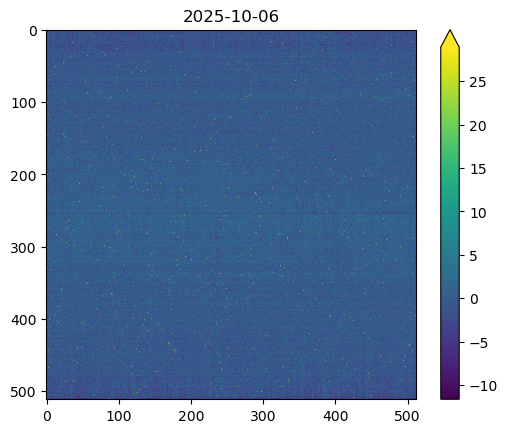

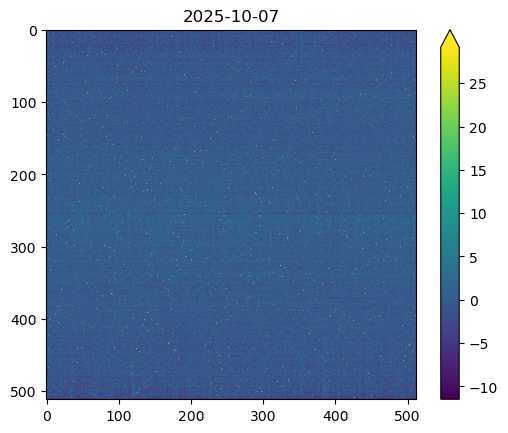

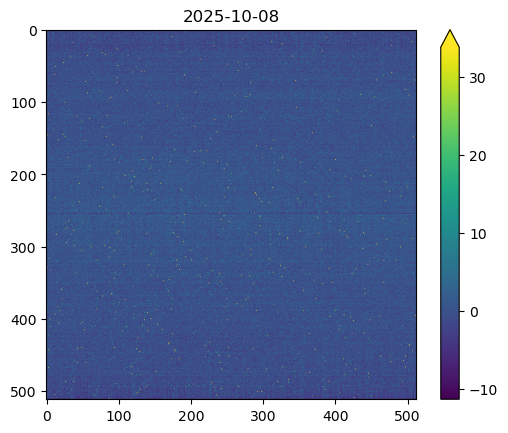

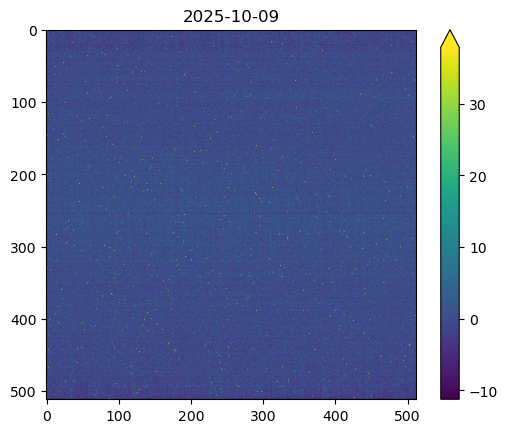

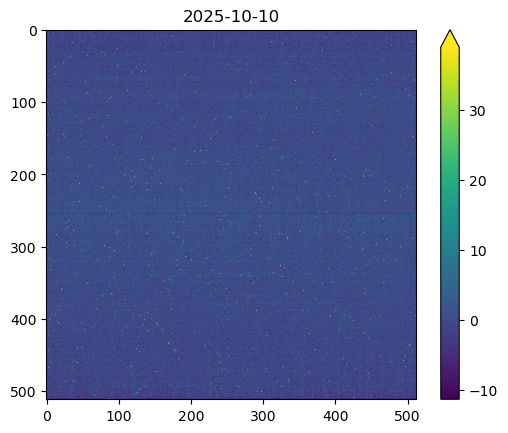

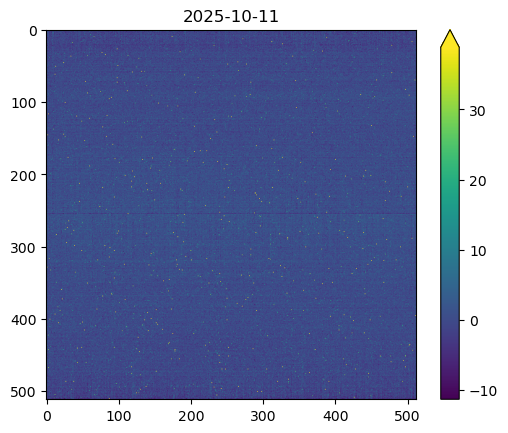

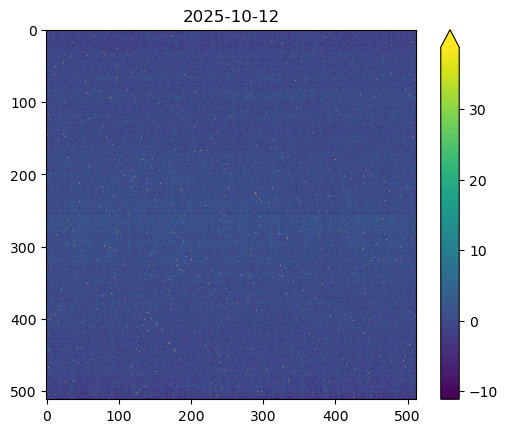

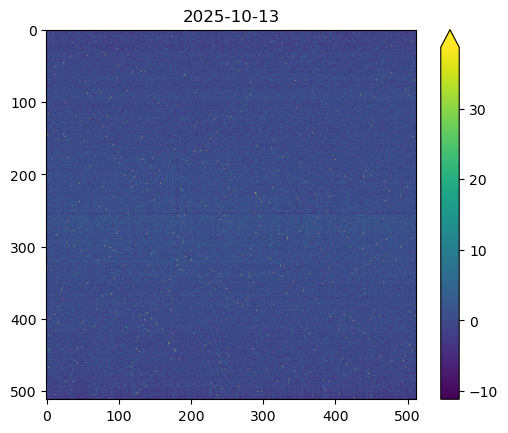

In [26]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from glide.common_components import constants
from glide.common_components.utils import circular_mask

# setup
channel = 'WFI'

with xr.open_dataset(f'products/{channel}_FOV_AVG.nc') as ds:
    day = ds['day'].to_numpy()
    day_mean_img = ds['day_mean_img']
    day_median_img = ds['day_median_img']

day = day.astype('datetime64[D]')


fov_mask = circular_mask(constants.NPIX[channel],constants.MASK_L1A_FOV_R[channel])

for i in range(10):

    plt.imshow(day_mean_img[i], vmax=np.percentile(day_mean_img[i], 99.9))
    plt.title(day[i].astype(str))
    plt.colorbar(extend="max")
    plt.show()
